In [1]:
from Tools.analysis_tools import *

## Performance Analysis:

This notebook loads and analyzes all the configuration files and results across various network architectures and datasets. Flexible filtering options allow for a detailed and customizable evaluation of network performance, enabling comprehensive comparisons across different configurations.

In [2]:
# Percorso della cartella contenente i file CSV degli encoder
encoder_folder = "Encoder Analysis Data"

# Carica i dati
encoder_data = load_encoder_analysis_data(encoder_folder)


# Order the dataset
config_file = 'encoderDatabase.json'
enriched_data = enrich_analysis_with_config(encoder_data, config_file)

# Visualizza i dati caricati
print(encoder_data.head())


Caricando dati da: Encoder Analysis Data/15,10,5.csv
Caricando dati da: Encoder Analysis Data/Test5-15.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise5,15.csv
Caricando dati da: Encoder Analysis Data/Model15.csv
Caricando dati da: Encoder Analysis Data/30-20.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise0,5.csv
Caricando dati da: Encoder Analysis Data/30-20_Noise10,0.csv
Caricando dati da: Encoder Analysis Data/Test4-15.csv
Caricando dati da: Encoder Analysis Data/30-20,15.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise5,5.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise15,0.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise5,10.csv
Caricando dati da: Encoder Analysis Data/30-20,10.csv
Caricando dati da: Encoder Analysis Data/30-20,5.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise0,10.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise10,5.csv
Caricando dati da: Encoder Analysis Data/Test-15.csv
Caricando dati da: Encoder Analysis

In [3]:
# Lista dei filtri

'''
filter_type: equals o range
filter_value: valore del parametro (numero o range)
'''

filters = [
    {"param_name": "tau", "filter_type": "equals", "filter_value": 15},
    #{"param_name": "Model Name", "filter_type": "equals", "filter_value": "Test1-15"},
    #{"param_name": "Model Name", "filter_type": "equals", "filter_value": "Test2-15"},
   # {"param_name": "alpha", "filter_type": "equals", "filter_value": 0}
   # {"param_name": "batch_size", "filter_type": "equals", "filter_value": 1000}

]

sorted_data = filter_by_config_params(enriched_data, filters,True)
filtered_data = sort_by_alpha_and_beta(sorted_data,"alpha","beta")

Plot of the metrics for the raw outputs

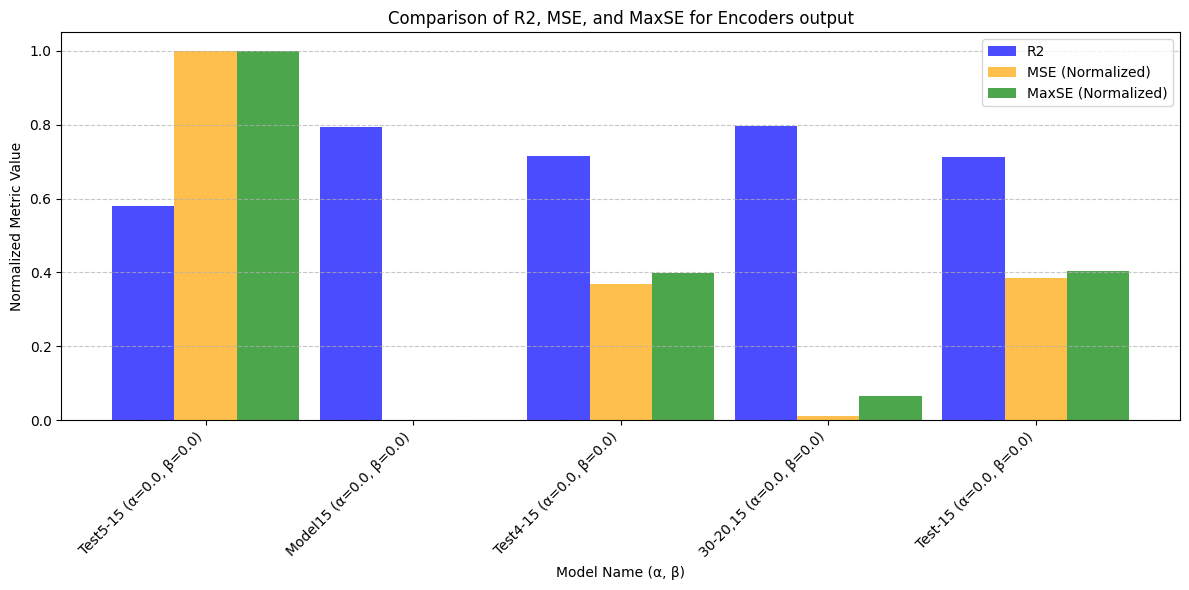

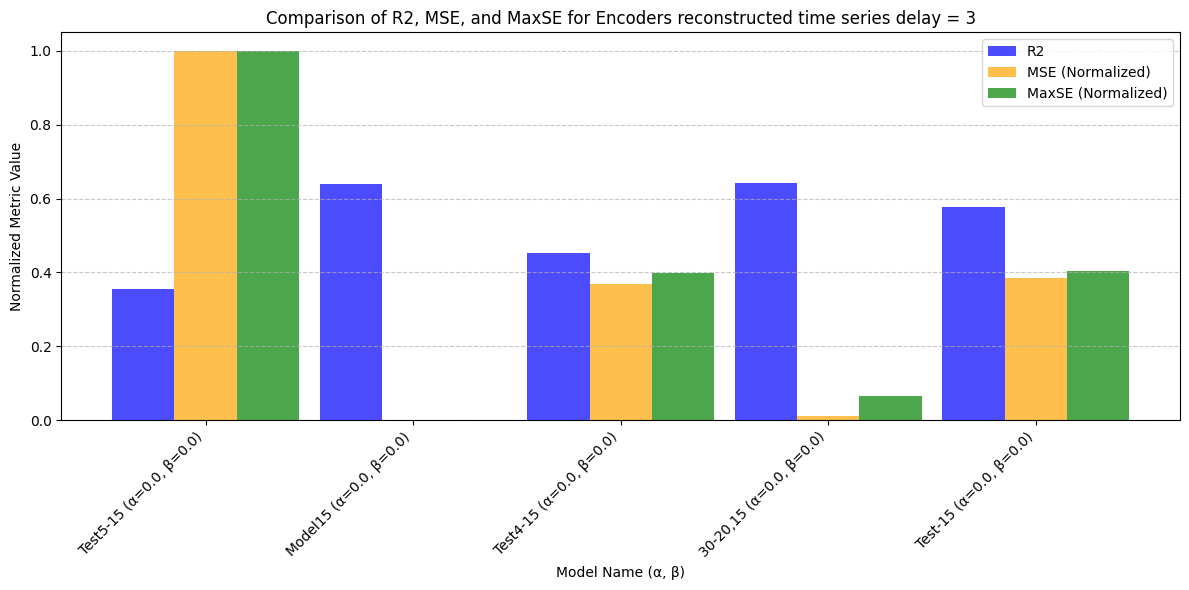

In [4]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z2 R2 Mean", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders output"
)
plot_z_metrics(
    data=filtered_data, 
    r2_col="PCA R2 Time Signal Z2", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders reconstructed time series delay = 3"
)

This graph illustrates the reconstructed principal components (PCs) of the output data from the validation dataset.

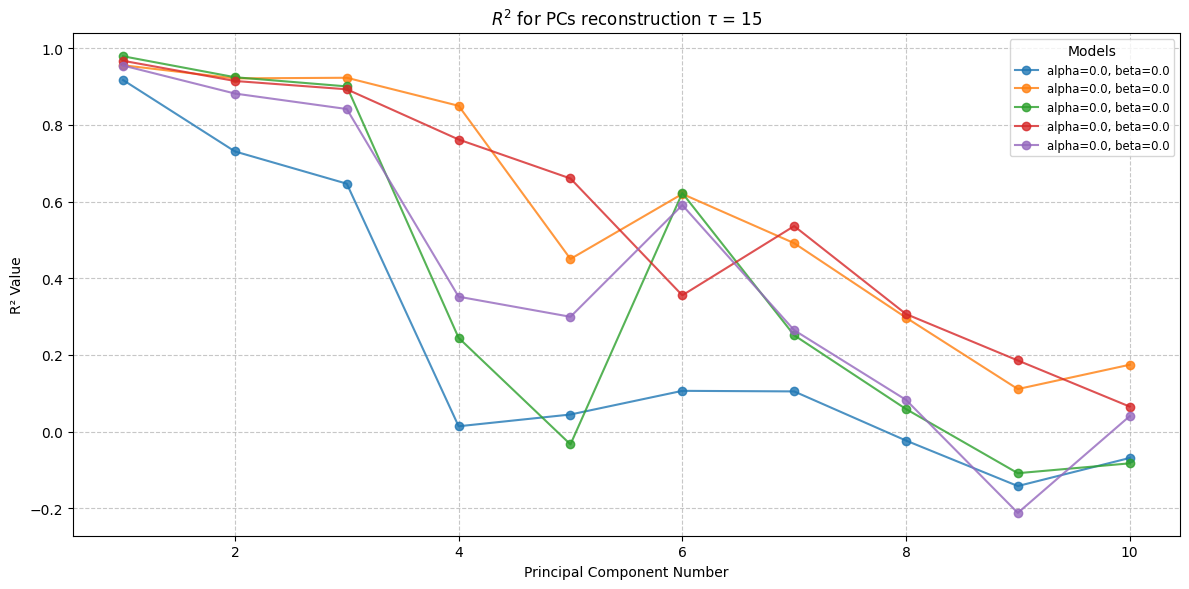

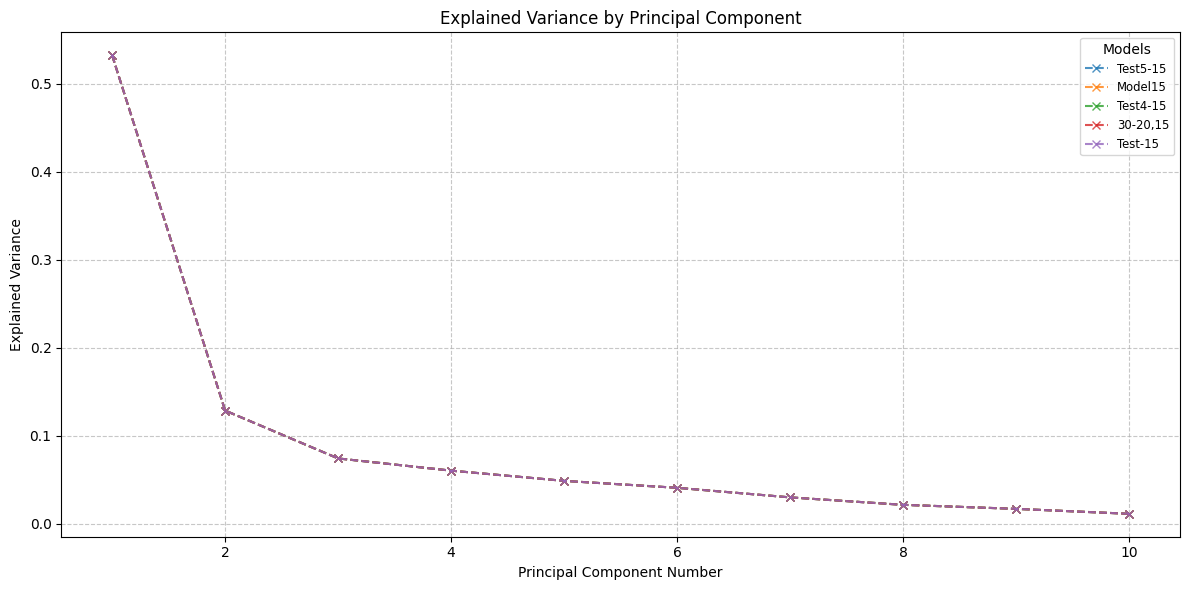

In [5]:
plot_r2_and_variance_separate(
    data=filtered_data, 
    r2_col="PCA R2 Z2 PC", 
    variance_col="Varianzce Explained Z2",
    r2_title = r"$R^2$ for PCs reconstruction $\tau$ = 15"   
)



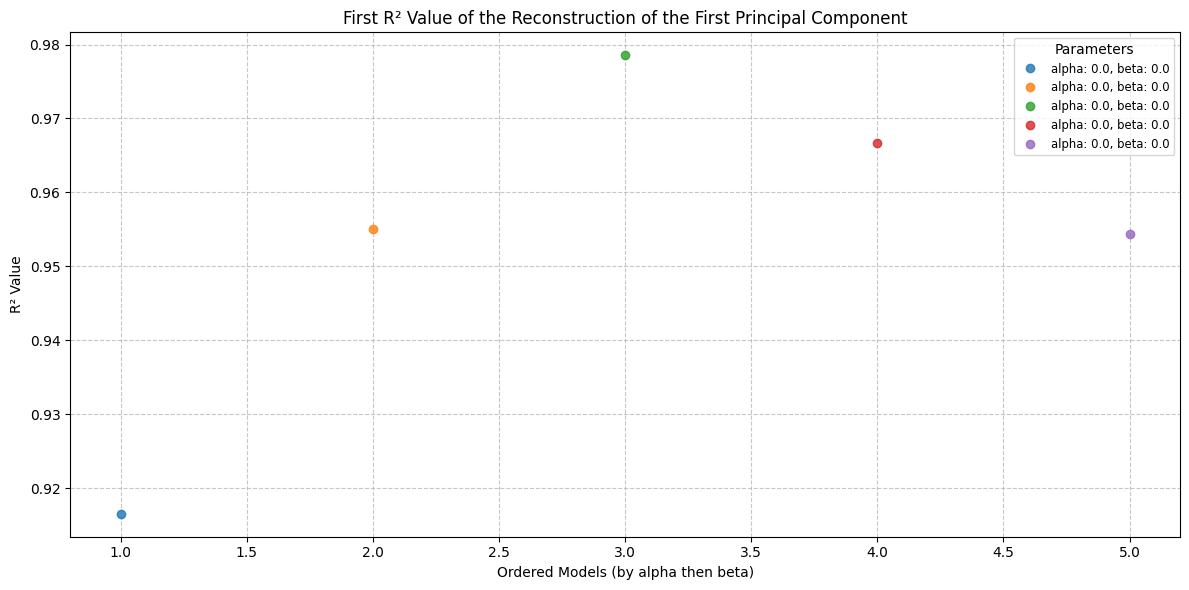

In [6]:
def plot_first_pc(data, r2_col):
    """
    Plot the first R² value for the reconstruction of the first principal components across datasets,
    ordering points according to alpha (fixed) then increasing beta.
    
    Parameters:
    - data: DataFrame with the data.
    - r2_col: Name of the column with R² values.
    """
    # Sort data by alpha then beta (adjust columns names if necessary)
    sorted_data = data.sort_values(by=["alpha", "beta"])
    
    plt.figure(figsize=(12, 6))
    
    # Use the order index as x coordinate
    for i, (_, row) in enumerate(sorted_data.iterrows()):
        r2_values = row[r2_col]
        if isinstance(r2_values, list) and len(r2_values) > 0:
            first_r2_value = r2_values[0]
            label = f"alpha: {row['alpha']}, beta: {row['beta']}"
            plt.plot(i + 1, first_r2_value, marker='o', linestyle='', label=label, alpha=0.8)
    
    plt.title("First R² Value of the Reconstruction of the First Principal Component")
    plt.xlabel("Ordered Models (by alpha then beta)")
    plt.ylabel("R² Value")
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    
    # Only add the legend if there is at least one labeled point.
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(title="Parameters", loc="best", fontsize="small")
    
    plt.tight_layout()
    plt.show()

import ast
import re

def safe_literal_eval(s):
    # Remove np.float32 wrappers
    # This replaces patterns like np.float32(0.943848) with just 0.943848.
    s_clean = re.sub(r'np\.float32\(([^)]+)\)', r'\1', s)
    return ast.literal_eval(s_clean)

filtered_data["PCA R2 Z2 PC"] = filtered_data["PCA R2 Z2 PC"].apply(
    lambda x: safe_literal_eval(x) if isinstance(x, str) else x
)

# Now call the plotting function
plot_first_pc(filtered_data, "PCA R2 Z2 PC")